# Computational Cost And Throughput

        ## Manuscript targets
        - `Methodology / Timing and Throughput Method`
- `Results / Computational cost`
- `Figure the computational cost`

        ## Primary inputs
        - `share/results/technical/throughput_detail.tsv`
- `share/notebooks/srr_queue.db`

        ## Rebuild scripts
        - `share/scripts/analysis/11_compute_pipeline_throughput.py`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

The throughput table stores per-stage timing, read volume, and core counts. This notebook turns that table into per-stage core-hours-per-GB summaries and paired alignment-time comparisons, and optionally reconstructs endpoint download summaries from the local queue database.


In [1]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    # --- Standardized Plotting Configuration ---
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })
    sns.set_theme(style="whitegrid", palette="colorblind")
    plt.rcParams.update({"font.family": "sans-serif"})
    # -------------------------------------------
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [2]:
REBUILD = False
if REBUILD:
    run_script("share/scripts/analysis/11_compute_pipeline_throughput.py")

throughput = load_table(TECH / "throughput_detail.tsv")
numeric_cols = [
    "duration_sec",
    "cores_used",
    "total_reads_M",
    "read_length",
    "fastq_mb",
    "mb_per_sec",
    "mb_per_sec_per_core",
    "reads_per_sec",
]
for col in numeric_cols:
    throughput[col] = pd.to_numeric(throughput[col], errors="coerce")

throughput["fastq_gb"] = throughput["fastq_mb"] / 1024
throughput["core_hours"] = throughput["duration_sec"] * throughput["cores_used"] / 3600
throughput["core_hours_per_gb"] = throughput["core_hours"] / throughput["fastq_gb"]
throughput.head()


,SRR_ID,project_id,category,stage,mode,duration_sec,cores_used,total_reads_M,read_length,fastq_mb,mb_per_sec,mb_per_sec_per_core,reads_per_sec,fastq_gb,core_hours,core_hours_per_gb
0,SRR26067916,PRJNA1014106,align,align_untrimmed,untrimmed,4199.0,36,483.38,150.0,161344.71,38.42,1.07,115117.33,157.563193,41.99,0.266496
1,SRR26067916,PRJNA1014106,count,count_untrimmed,untrimmed,20.0,36,483.38,150.0,161344.71,8067.24,224.09,24168883.85,157.563193,0.20,0.001269
2,SRR26067916,PRJNA1014106,mode_total,mode_untrimmed_total,untrimmed,4219.0,36,483.38,150.0,161344.71,38.24,1.06,114571.62,157.563193,42.19,0.267766
3,SRR26067916,PRJNA1014106,trim,trim_adapter_only,adapter_only,1275.0,36,483.38,150.0,161344.71,126.54,3.52,379119.75,157.563193,12.75,0.080920
4,SRR26067916,PRJNA1014106,align,align_adapter_only,adapter_only,4197.0,36,483.38,150.0,161344.71,38.44,1.07,115172.19,157.563193,41.97,0.266369


In [3]:
stage_summary = (
    throughput.groupby(["category", "mode"], dropna=False)
    .agg(
        n_records=("SRR_ID", "size"),
        median_core_hours_per_gb=("core_hours_per_gb", "median"),
        q1_core_hours_per_gb=("core_hours_per_gb", lambda s: s.quantile(0.25)),
        q3_core_hours_per_gb=("core_hours_per_gb", lambda s: s.quantile(0.75)),
        median_mb_per_sec=("mb_per_sec", "median"),
    )
    .reset_index()
    .sort_values(["category", "mode"])
)

align_pairs = throughput.loc[throughput["category"].eq("align")].pivot_table(
    index="SRR_ID",
    columns="mode",
    values="duration_sec",
    aggfunc="median",
)
align_pairs = align_pairs.dropna(subset=["untrimmed", "adapter_only"])
align_pairs["ratio_untrimmed_over_adapter"] = (
    align_pairs["untrimmed"] / align_pairs["adapter_only"]
)

display(stage_summary)
display(
    pd.Series(
        {
            "paired_alignment_observations": len(align_pairs),
            "median_untrimmed_over_adapter_ratio": align_pairs["ratio_untrimmed_over_adapter"].median(),
            "mean_untrimmed_over_adapter_ratio": align_pairs["ratio_untrimmed_over_adapter"].mean(),
        }
    ).to_frame("value")
)


,category,mode,n_records,median_core_hours_per_gb,q1_core_hours_per_gb,q3_core_hours_per_gb,median_mb_per_sec
0,align,P10,1058,0.947934,0.429114,1.222668,10.800
1,align,P20,1069,1.021673,0.464490,1.362852,10.020
2,align,P35,591,0.239988,0.011325,1.092862,42.670
3,align,P5,1051,0.947988,0.446127,1.227901,10.800
4,align,adapter_only,1025,1.081842,0.644445,1.615335,9.470
5,align,untrimmed,966,3.707565,2.493553,6.505154,2.765
6,count,P10,1049,0.013079,0.008605,0.019745,782.940
7,count,P20,1061,0.012886,0.008143,0.019554,794.650
8,count,P35,589,0.008903,0.001146,0.021744,1150.220
9,count,P5,1045,0.013072,0.008538,0.019620,783.340


,value
paired_alignment_observations,908.000000
median_untrimmed_over_adapter_ratio,2.909150
mean_untrimmed_over_adapter_ratio,4.148513


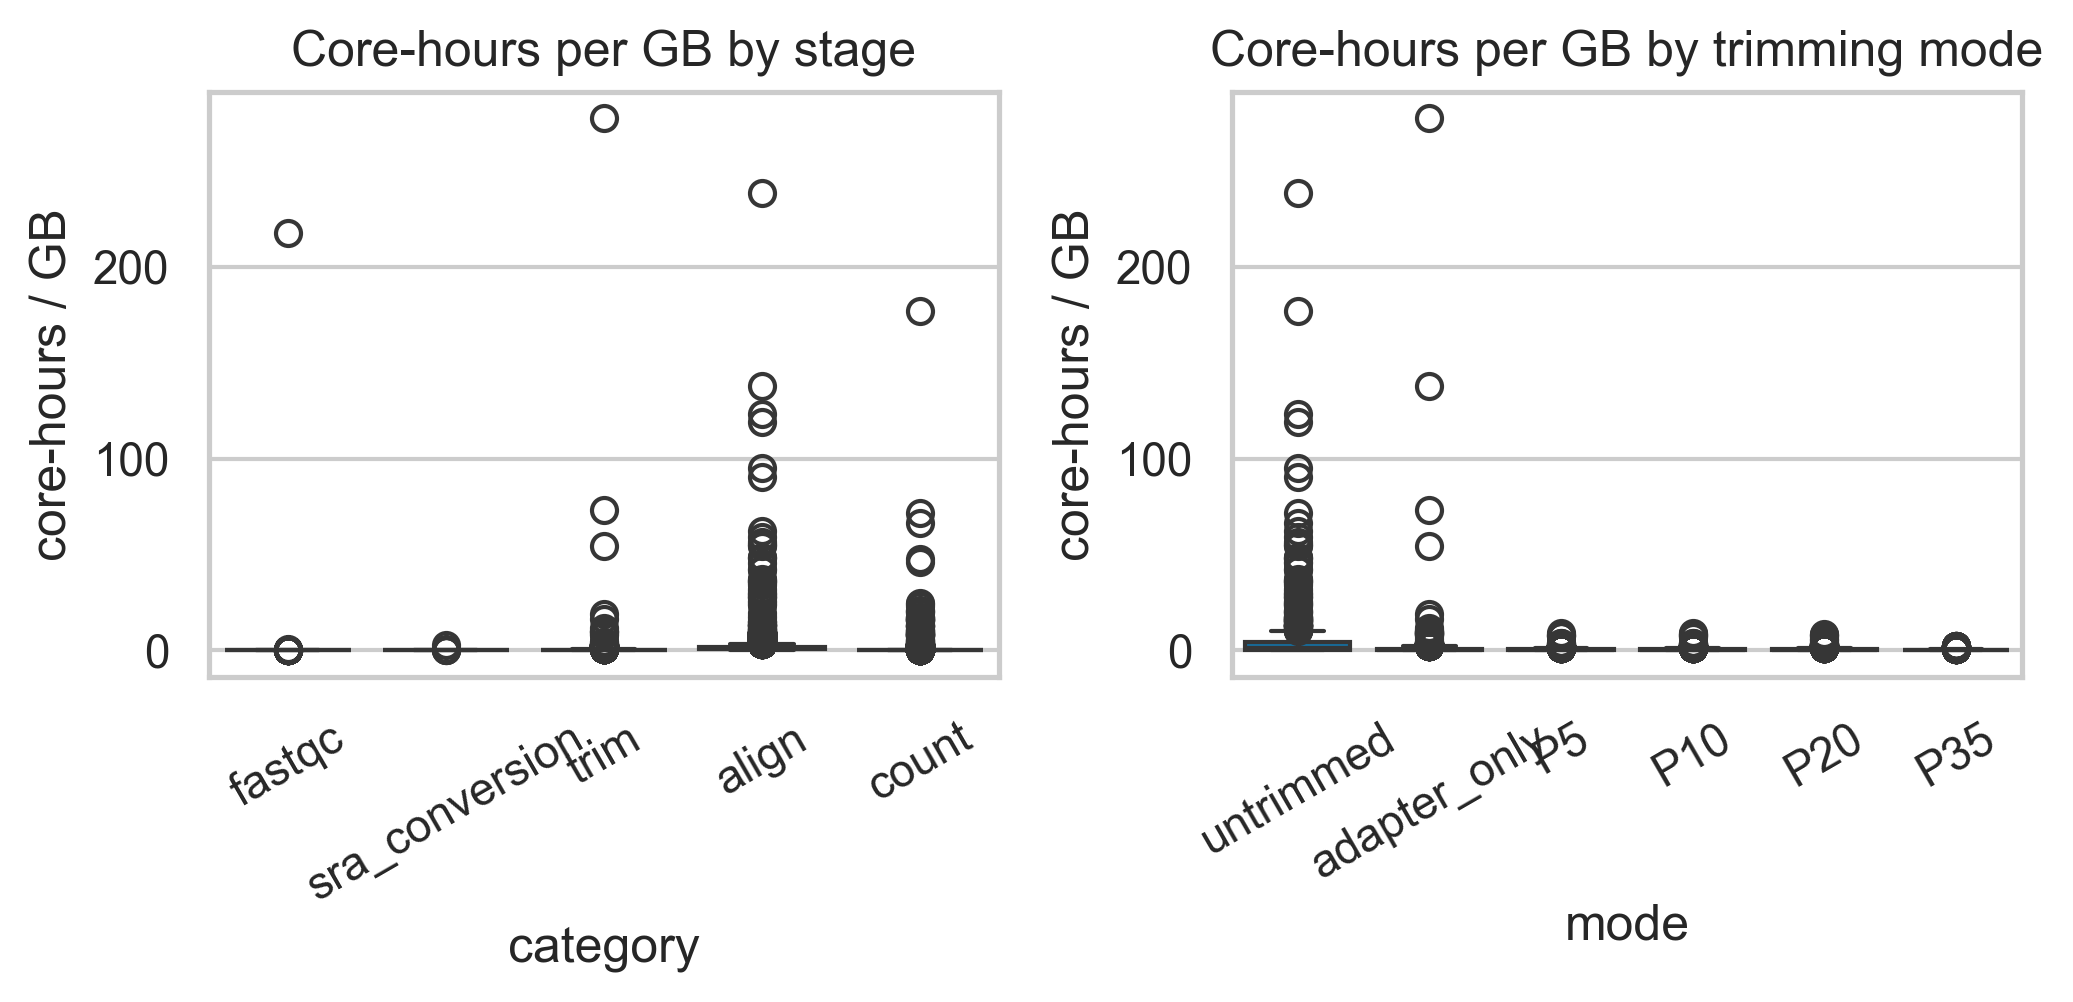

In [4]:
plot_df = throughput.loc[
    throughput["category"].isin(["fastqc", "sra_conversion", "trim", "align", "count"])
].copy()
plot_df["label"] = np.where(
    plot_df["mode"].fillna("").eq(""),
    plot_df["category"],
    plot_df["category"] + ":" + plot_df["mode"].astype(str),
)

categories = ["fastqc", "sra_conversion", "trim", "align", "count"]
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))

if sns is not None:
    sns.boxplot(
        data=plot_df,
        x="category",
        y="core_hours_per_gb",
        order=categories,
        ax=axes[0],
    )
    sns.boxplot(
        data=plot_df.loc[plot_df["category"].isin(["trim", "align", "count"])],
        x="mode",
        y="core_hours_per_gb",
        order=["untrimmed", "adapter_only", "P5", "P10", "P20", "P35"],
        ax=axes[1],
    )
else:
    axes[0].boxplot(
        [plot_df.loc[plot_df["category"].eq(cat), "core_hours_per_gb"].dropna() for cat in categories],
        tick_labels=categories,
    )
    axes[1].boxplot(
        [
            plot_df.loc[plot_df["mode"].eq(mode), "core_hours_per_gb"].dropna()
            for mode in ["untrimmed", "adapter_only", "P5", "P10", "P20", "P35"]
        ],
        tick_labels=["untrimmed", "adapter_only", "P5", "P10", "P20", "P35"],
    )

axes[0].set_title("Core-hours per GB by stage")
axes[0].set_ylabel("core-hours / GB")
axes[0].tick_params(axis="x", rotation=30)

axes[1].set_title("Core-hours per GB by trimming mode")
axes[1].set_ylabel("core-hours / GB")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

from pathlib import Path
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/computational_cost_and_throughput_fig1.png", bbox_inches="tight")
fig.savefig("figures/computational_cost_and_throughput_fig1.pdf", bbox_inches="tight")
fig.savefig("figures/computational_cost_and_throughput_fig1.svg", bbox_inches="tight")

In [5]:
if NOTEBOOK_DB.exists():
    import sqlite3

    con = sqlite3.connect(str(NOTEBOOK_DB))
    try:
        fetch = pd.read_sql_query(
            "SELECT * FROM fetch_attempts",
            con,
            parse_dates=["started_at", "finished_at"],
        )
        fetch["duration_sec"] = (fetch["finished_at"] - fetch["started_at"]).dt.total_seconds()
        fetch["mb_downloaded"] = pd.to_numeric(fetch["bytes_downloaded"], errors="coerce") / 1e6
        fetch["mb_per_sec"] = fetch["mb_downloaded"] / fetch["duration_sec"]

        endpoint_summary = (
            fetch.groupby("endpoint")
            .agg(
                attempts=("srr_id", "size"),
                successes=("status", lambda s: int((s == "success").sum())),
                failed=("status", lambda s: int((s == "failed").sum())),
                median_mb_per_sec=("mb_per_sec", "median"),
            )
            .reset_index()
            .sort_values("endpoint")
        )
        display(endpoint_summary)
    except Exception as e:
        print(f"fetch_attempts table not available or empty: {e}")
    finally:
        con.close()
else:
    print("Local queue database not available; skipping endpoint-download diagnostics.")


fetch_attempts table not available or empty: Execution failed on sql 'SELECT * FROM fetch_attempts': no such table: fetch_attempts
